# Coral Bleaching Risk Analysis
## Notebook 01 — Data Loading and Cleaning

**Dataset:** Global Coral Bleaching Database 1980–2020  
**Source:** Van Woesik & Kratochwill (2022), BCO-DMO / Kaggle  
**Author:** Giulia Balducci  

---

## Contents
1. Load and inspect the raw dataset
2. Understand the structure, variables, and data types
3. Identify missing values, handling strategy deferred to EDA
4. Save a clean version of the dataset for EDA

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Setting pandas to show all columns: the dataset has 62 columns and pandas truncates by default
pd.set_option('display.max_columns', None)

In [2]:
# Project colour palette: ocean themed 🌊
color_primary = 'teal'
color_secondary = 'coral'  
color_accent = 'turquoise'

In [3]:
df = pd.read_csv('../data/raw/global_bleaching_environmental.csv', low_memory=False)

## 1. Initial Data Exploration
Getting a first look at the dataset: structure, columns, data types, and size.

In [4]:
print(df.shape)
df.info()

(41361, 62)


<class 'pandas.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  str    
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  str    
 6   Reef_ID                                41361 non-null  str    
 7   Realm_Name                             41361 non-null  str    
 8   Ecoregion_Name                         41361 non-null  str    
 9   Country_Name                           41361 non-null  str    
 10  State_Island_Province_Name             41361 non-null  str    
 11  City_Town_Nam

In [5]:
df.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,State_Island_Province_Name,City_Town_Name,Site_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Date_Day,Date_Month,Date_Year,Depth_m,Substrate_Name,Percent_Cover,Bleaching_Level,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,Havana,Havana,Puntilla,8519.23,Exposed,0.0287,49.90,15,9,2005,10,nd,nd,nd,50.2,301.61,302.05,300.67,296.72,304.69,1.6,8,-0.46,1,0,-3.56,2.24,0,3.13,17,3,0,1.63,7.88,0.98,-0.8,1.6,-6.12,1.83,-2.17,0,1.09,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,Society Islands,Moorea,nd,1431.62,Exposed,0.0262,51.20,15,3,1991,14,nd,nd,nd,50.7,262.15,303.30,300.73,297.58,305.01,1.12,2,1.29,1,0,-2.73,3.1,0.5,2.77,13.25,2,0.26,1.48,11.41,0.72,1.29,1.12,-4.42,3.00,-1.26,0.25,0.93,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,British Virgin Islands,Peter Island,Coral Gardens,182.33,Exposed,0.0429,61.52,15,1,2006,7,nd,nd,nd,50.9,298.79,299.18,300.32,297.12,304.14,1.22,8,0.04,1,0,-2.92,2.83,16,4.52,23,3,0,2.45,16.24,1.26,-2.64,1.22,-4.69,2.31,-1.49,7,1.31,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3219,313.13,Exposed,0.0424,65.39,15,4,2006,9.02,nd,nd,nd,50.9,300.16,299.61,300.38,297.25,304.07,1.19,3,-0.07,1,0,-2.77,2.47,22,4.75,24,3,0,2.37,16.73,1.07,-2.27,1.19,-4.63,2.19,-1.49,3,0.94,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3194,792,Exposed,0.0424,65.39,15,4,2006,12.50,nd,nd,nd,50.9,300.15,299.7,300.38,296.63,303.76,1.18,3,0,1,0,-2.84,2.3,16,4.16,20,3,0,2.24,13.86,1.16,-2.19,1.18,-5.25,1.87,-1.5,3,1.33,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


## 2. Data Cleaning

### Checking for Duplicates
Checking for duplicate rows before any cleaning.

In [6]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


### Missing Values
This dataset uses `nd` (no data) instead of standard NaN to encode missing values.
Identifying which columns are affected, handling strategy deferred to EDA.

In [7]:
# Count 'nd' values per column
nd_counts = (df == 'nd').sum()
nd_counts[nd_counts > 0].sort_values(ascending=False)

Site_Comments                            39104
Bleaching_Comments                       38692
Sample_Comments                          38403
Site_Name                                34429
Bleaching_Level                          18830
Substrate_Name                           12668
Reef_ID                                  12540
Percent_Cover                            12455
Percent_Bleaching                         6846
Depth_m                                   1799
City_Town_Name                            1133
SSTA_Minimum                               176
TSA                                        148
SSTA_Frequency                             148
SSTA_DHW                                   148
SSTA                                       148
Temperature_Kelvin                         148
TSA_Frequency                              148
TSA_DHW                                    148
SSTA_DHW_Standard_Deviation                132
SSTA_DHWMax                                132
SSTA_Frequenc

### Strategy
Handling strategy deferred to EDA: dropping rows without first examining the geographic and temporal distribution of missing values risks introducing bias.

### Deep Dive: Percent_Bleaching
This is our target variable: inspecting it closely before any transformation.

In [8]:
# Checking Percent_Bleaching column to understand the data before deciding how to handle missing values
df['Percent_Bleaching'].head(20)

0      50.2
1      50.7
2      50.9
3      50.9
4      50.9
5        51
6      51.3
7     51.38
8      51.4
9     51.53
10     51.7
11     51.7
12     51.8
13     51.8
14     51.8
15       52
16       52
17       52
18       52
19       52
Name: Percent_Bleaching, dtype: str

In [9]:
# Check for non-numeric values in Percent_Bleaching
mask = pd.to_numeric(df['Percent_Bleaching'], errors='coerce').isna()
df['Percent_Bleaching'][mask].unique()

<StringArray>
['nd']
Length: 1, dtype: str

### Cleaning Percent_Bleaching
Only `nd` found as non-numeric value. Replacing with NaN, then converting to float.

In [10]:
# Replacing 'nd' with NaN
df['Percent_Bleaching'] = df['Percent_Bleaching'].replace('nd', np.nan)

In [11]:
# Converting to float
df['Percent_Bleaching'] = df['Percent_Bleaching'].astype(float)

In [12]:
# Sanity check: NaN count in Percent_Bleaching after 'nd' replacement
# 6846 NaN are original missing values from the raw dataset, not introduced during cleaning
print(df['Percent_Bleaching'].isna().sum())

6846


In [13]:
# Descriptive statistics for Percent_Bleaching
df['Percent_Bleaching'].describe().T

count    34515.000000
mean         9.619465
std         20.190956
min          0.000000
25%          0.000000
50%          0.250000
75%          6.000000
max        100.000000
Name: Percent_Bleaching, dtype: float64

### Distribution of Percent_Bleaching
The statistical summary suggests a heavily right-skewed distribution: 75% of observations show less than 6% bleaching.
Visualising to confirm before deciding how to handle NaN values and class imbalance in modelling.


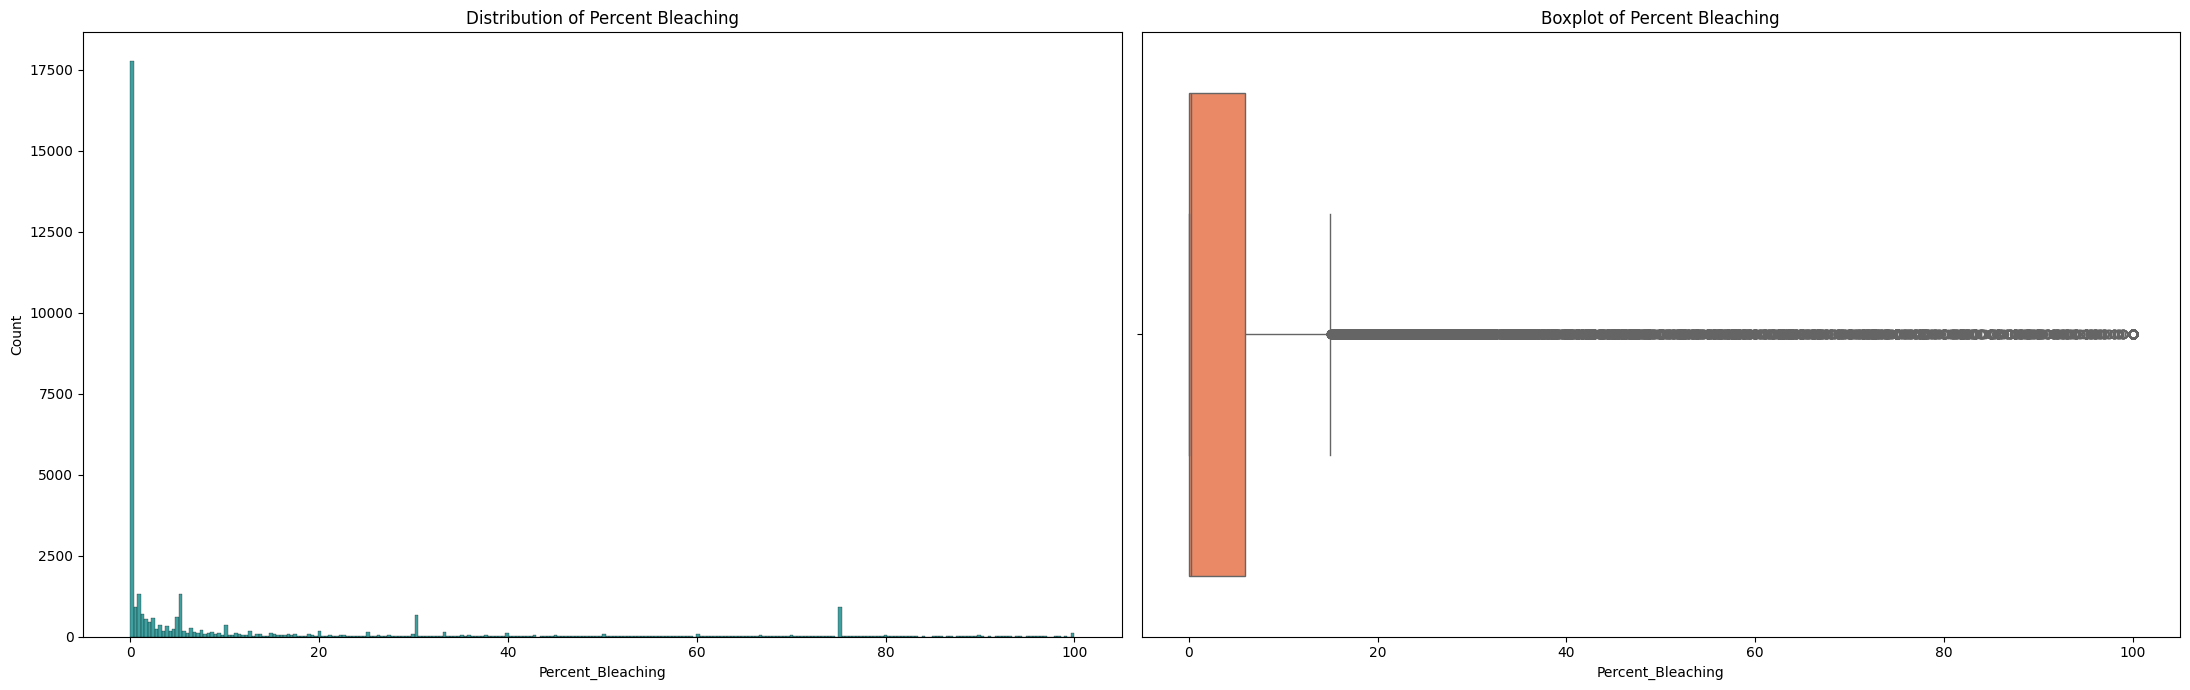

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7))

sns.histplot(data=df, x='Percent_Bleaching', ax=ax1, color = color_primary)
sns.boxplot(data=df, x='Percent_Bleaching', ax=ax2, color = color_secondary)

ax1.set_title('Distribution of Percent Bleaching')
ax2.set_title('Boxplot of Percent Bleaching')

plt.tight_layout()
plt.savefig('../outputs/figures/percent_bleaching_distribution.png')
plt.show()

### Next Steps
Skewed distribution confirmed visually. Proceeding to clean the remaining columns: replacing `nd` with NaN, converting data types, and validating timestamps and value ranges.

In [15]:
# Extract column names with nd values as a list
nd_columns = nd_counts[nd_counts > 0].index.tolist()
nd_columns

['Reef_ID',
 'Ecoregion_Name',
 'Country_Name',
 'State_Island_Province_Name',
 'City_Town_Name',
 'Site_Name',
 'Distance_to_Shore',
 'Turbidity',
 'Depth_m',
 'Substrate_Name',
 'Percent_Cover',
 'Bleaching_Level',
 'Percent_Bleaching',
 'ClimSST',
 'Temperature_Kelvin',
 'Temperature_Mean',
 'Temperature_Minimum',
 'Temperature_Maximum',
 'Temperature_Kelvin_Standard_Deviation',
 'Windspeed',
 'SSTA',
 'SSTA_Standard_Deviation',
 'SSTA_Mean',
 'SSTA_Minimum',
 'SSTA_Maximum',
 'SSTA_Frequency',
 'SSTA_Frequency_Standard_Deviation',
 'SSTA_FrequencyMax',
 'SSTA_FrequencyMean',
 'SSTA_DHW',
 'SSTA_DHW_Standard_Deviation',
 'SSTA_DHWMax',
 'SSTA_DHWMean',
 'TSA',
 'TSA_Standard_Deviation',
 'TSA_Minimum',
 'TSA_Maximum',
 'TSA_Mean',
 'TSA_Frequency',
 'TSA_Frequency_Standard_Deviation',
 'TSA_FrequencyMax',
 'TSA_FrequencyMean',
 'TSA_DHW',
 'TSA_DHW_Standard_Deviation',
 'TSA_DHWMax',
 'TSA_DHWMean',
 'Site_Comments',
 'Sample_Comments',
 'Bleaching_Comments']

In [16]:
# Columns to exclude because they contain text data and should remain as strings
# Percentage Bleaching added to the list because handled separately in target variable section
cols_to_exclude = ['Reef_ID', 'Ecoregion_Name', 'Country_Name', 
                   'State_Island_Province_Name', 'City_Town_Name', 
                   'Site_Name', 'Substrate_Name', 'Bleaching_Level',
                   'Site_Comments', 'Sample_Comments', 'Bleaching_Comments',
                   'Percent_Bleaching'] 


In [17]:
# Replacing 'nd' with NaN in the string columns
# For Percentage Bleaching the 'nd' values were already converted to NaN during the deep dive exploration
for col in cols_to_exclude:
    df[col] = df[col].replace('nd', np.nan)


In [18]:
# Columns to convert from object to float
cols_to_convert = [col for col in nd_columns if col not in cols_to_exclude]
print(cols_to_convert)

['Distance_to_Shore', 'Turbidity', 'Depth_m', 'Percent_Cover', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean']


In [19]:
# Replacing 'nd' with NaN and converting the columns to floats
for col in cols_to_convert:
    df[col] = df[col].replace('nd', np.nan).astype(float)

In [20]:
# Checking the data types after conversion
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  str    
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  str    
 6   Reef_ID                                28821 non-null  str    
 7   Realm_Name                             41361 non-null  str    
 8   Ecoregion_Name                         41358 non-null  str    
 9   Country_Name                           41360 non-null  str    
 10  State_Island_Province_Name             41262 non-null  str    
 11  City_Town_Nam

### Timestamp Parsing
Converting the `Date` column from string to datetime, validating the range (1980–2020) and consistency with the `Date_Year`, `Date_Month`, `Date_Day` columns.


In [21]:
# Checking for consistency and confirming string type
df['Date']

0        2005-09-15
1        1991-03-15
2        2006-01-15
3        2006-04-15
4        2006-04-15
            ...    
41356    2019-05-28
41357    2019-05-16
41358    2019-05-16
41359    2019-05-29
41360    2019-05-29
Name: Date, Length: 41361, dtype: str

In [22]:
# Conversion from string to timestamp
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
# Validation of the range and check for NaT
date_min = df['Date'].min()
date_max = df['Date'].max()
nat_count = df['Date'].isna().sum()

print("Date range:", date_min, "→", date_max)
print("NaT:", nat_count)


Date range: 1980-06-15 00:00:00 → 2020-08-15 00:00:00
NaT: 0


In [24]:
# Consistency check: comparing ['Date'] column with ['Date_Year'], ['Date_Month'] and ['Date_Day']
mismatch = (
    (df['Date'].dt.year != df['Date_Year']) |
    (df['Date'].dt.month != df['Date_Month']) |
    (df['Date'].dt.day != df['Date_Day'])
)
print("Mismatches:", mismatch.sum())


Mismatches: 0


### Sanity Checks
Verifying that numeric columns contain physically plausible values: no out-of-range percentages, coordinates, temperatures, or depths.

In [25]:
# Checking for values above 100% and below 0% for the ['Percent_Bleaching']
print((df['Percent_Bleaching'] > 100).sum())
print((df['Percent_Bleaching'] < 0).sum())  

0
0


In [26]:
# Sanity check for coordinates: checking latitude and longitude
print("Latitude out of range:", ((df['Latitude_Degrees'] < -90) | (df['Latitude_Degrees'] > 90)).sum())
print("Longitude out of range:", ((df['Longitude_Degrees'] < -180) | (df['Longitude_Degrees'] > 180)).sum())


Latitude out of range: 0
Longitude out of range: 0


In [27]:
# Checking for Ocean Surface Temperature Range: 270-313 K
# Lower Value: sea water freezing temperature is 271 K, or −2°C
# Upper Value: extreme surface temperatures in the Persian Gulf can reach ~40°C (313 K)
print("Temperature_Kelvin out of range:", ((df['Temperature_Kelvin'] < 270) | (df['Temperature_Kelvin'] > 313)).sum())


Temperature_Kelvin out of range: 0


In [28]:
# Checking that ['Depth_m'] has no negative values
print("Depth_m negative values:", (df['Depth_m'] < 0).sum())


Depth_m negative values: 0


## 3. Saving the Cleaned Dataset
Saving the cleaned dataframe to `data/processed/` for use in the EDA notebook.
The raw data remains untouched in `data/raw/`.

In [29]:
# Save cleaned dataset
df.to_csv('../data/processed/bleaching_clean.csv', index=False)